In [2]:
import cv2
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## DOWNLOADING DATASET AND MAKING ARRAYS

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/emotion-detection-fer


In [4]:
def make_dataset(path):
  images=[]
  labels=[]
  l=0
  for label in os.listdir(path):
    label_path = os.path.join(path,label)
    for img in os.listdir(label_path):
      img_path=os.path.join(label_path,img)
      im = cv2.imread(img_path)
      im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
      images.append(im)
      labels.append(l)
    l+=1


  images = np.array(images, dtype='float32')
  images = np.reshape(images, (-1, 48, 48, 1))
  labels = np.array(labels,dtype='int8')
  images/=255.0
  images,labels = shuffle(images,labels,random_state=42)
  return images, labels

In [6]:
path = '/kaggle/input/emotion-detection-fer/'
x_train, y_train = make_dataset(path+'train')
x_test, y_test = make_dataset(path+'test')

In [7]:
print(np.shape(x_train))
print(np.shape(y_train))
print(np.shape(x_test))
print(np.shape(y_test))

(28709, 48, 48, 1)
(28709,)
(7178, 48, 48, 1)
(7178,)


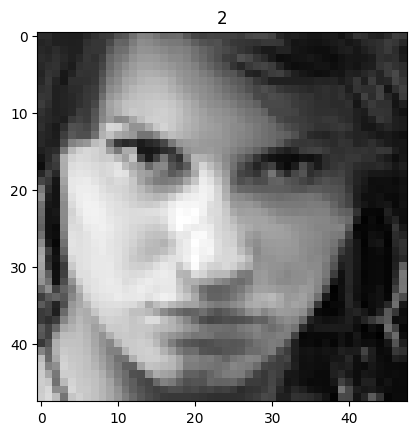

In [8]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

## ALL SET , LETS GO FOR MODEL

In [30]:
# Create data generator for augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_datagen.fit(x_train)

In [31]:
model = Sequential([
    Input(shape = (48,48,1)),

    Conv2D(512, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    # MaxPooling2D(pool_size=2),
    # Dropout(0.25),

    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),

    Conv2D(128 , kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    # MaxPooling2D(pool_size=2),
    # Dropout(0.25),

    Conv2D(128 , kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),

    Conv2D(256 , kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    # MaxPooling2D(pool_size=2),
    # Dropout(0.25),

    Conv2D(512, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),

    Flatten(),


    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    Dense(7, activation='softmax')

])

In [32]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_cb = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1)

In [ ]:
model.fit(train_datagen.flow(x_train, y_train, batch_size=64), epochs=100, validation_data=(x_test, y_test), callbacks=[checkpoint_cb])

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5702 - loss: 1.1352
Epoch 1: val_accuracy improved from -inf to 0.55419, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 212ms/step - accuracy: 0.5702 - loss: 1.1352 - val_accuracy: 0.5542 - val_loss: 1.1826
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5765 - loss: 1.1225
Epoch 2: val_accuracy improved from 0.55419 to 0.58721, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 82s 183ms/step - accuracy: 0.5765 - loss: 1.1225 - val_accuracy: 0.5872 - val_loss: 1.0942
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5830 - loss: 1.0882
Epoch 3: val_accuracy did not improve from 0.58721
449/449 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.5830 - loss: 1.0882 - val_accuracy: 0.5421 - val_loss: 1.2151
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6011 - loss: 1.0603
Epoch 4: val_accuracy improved from 0.58721 to 0.61034, saving model to best_model.h5


...

449/449 ━━━━━━━━━━━━━━━━━━━━ 84s 186ms/step - accuracy: 0.7015 - loss: 0.7939 - val_accuracy: 0.6719 - val_loss: 0.9212
Epoch 28/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7031 - loss: 0.7886
Epoch 28: val_accuracy did not improve from 0.67191
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7030 - loss: 0.7886 - val_accuracy: 0.6688 - val_loss: 0.9007
Epoch 29/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7044 - loss: 0.7881
Epoch 29: val_accuracy did not improve from 0.67191
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7044 - loss: 0.7881 - val_accuracy: 0.6343 - val_loss: 1.0409
Epoch 30/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7097 - loss: 0.7827
Epoch 30: val_accuracy did not improve from 0.67191
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7097 - loss: 0.7827 - val_accuracy: 0.6634 - val_loss: 0.9495
Epoch 31/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7184 - loss: 0.7651
Epoc

449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7160 - loss: 0.7665 - val_accuracy: 0.6736 - val_loss: 0.9168
Epoch 33/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7218 - loss: 0.7480
Epoch 33: val_accuracy did not improve from 0.67359
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.7218 - loss: 0.7481 - val_accuracy: 0.6558 - val_loss: 0.9759
Epoch 34/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7202 - loss: 0.7532
Epoch 34: val_accuracy did not improve from 0.67359
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.7202 - loss: 0.7533 - val_accuracy: 0.6580 - val_loss: 0.9685
Epoch 35/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7183 - loss: 0.7476
Epoch 35: val_accuracy improved from 0.67359 to 0.67442, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 182ms/step - accuracy: 0.7183 - loss: 0.7477 - val_accuracy: 0.6744 - val_loss: 0.9505
Epoch 36/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7223 - loss: 0.7458
Epoch 36: val_accuracy did not improve from 0.67442
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.7223 - loss: 0.7457 - val_accuracy: 0.6682 - val_loss: 0.9738
Epoch 37/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7238 - loss: 0.7422
Epoch 37: val_accuracy did not improve from 0.67442
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7238 - loss: 0.7422 - val_accuracy: 0.6702 - val_loss: 0.9576
Epoch 38/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7292 - loss: 0.7273
Epoch 38: val_accuracy did not improve from 0.67442
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7292 - loss: 0.7273 - val_accuracy: 0.6739 - val_loss: 0.9537
Epoch 39/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7320 - loss: 0.7189
Epo

449/449 ━━━━━━━━━━━━━━━━━━━━ 84s 186ms/step - accuracy: 0.7357 - loss: 0.7109 - val_accuracy: 0.6767 - val_loss: 0.9616
Epoch 43/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7393 - loss: 0.6997
Epoch 43: val_accuracy did not improve from 0.67665
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.7393 - loss: 0.6997 - val_accuracy: 0.6757 - val_loss: 0.9427
Epoch 44/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7423 - loss: 0.6993
Epoch 44: val_accuracy improved from 0.67665 to 0.68222, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 181ms/step - accuracy: 0.7423 - loss: 0.6993 - val_accuracy: 0.6822 - val_loss: 0.9490
Epoch 45/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7495 - loss: 0.6678
Epoch 45: val_accuracy did not improve from 0.68222
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7495 - loss: 0.6679 - val_accuracy: 0.6769 - val_loss: 0.9361
Epoch 46/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7505 - loss: 0.6725
Epoch 46: val_accuracy did not improve from 0.68222
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7505 - loss: 0.6726 - val_accuracy: 0.6573 - val_loss: 0.9966
Epoch 47/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7475 - loss: 0.6762
Epoch 47: val_accuracy did not improve from 0.68222
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.7475 - loss: 0.6762 - val_accuracy: 0.6656 - val_loss: 0.9775
Epoch 48/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7470 - loss: 0.6772
Epoc

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest accuracy: {100*test_acc:.4f}%")